In [4]:
# ============================================================
# CAPSTONE — CONNECT AND PREPARE YOUR GITHUB REPOSITORY
# ============================================================

from pathlib import Path
import subprocess
import shutil
import os

REPO_URL = "https://github.com/Imvixh/flyrank-ml-internship.git"
ROOT = Path("/content/flyrank-ml-internship")

# Remove incomplete runtime clone if present
if ROOT.exists():
    shutil.rmtree(ROOT)

print("Downloading YOUR GitHub repository...")
print("Repository:", REPO_URL)

# Clone YOUR repository
result = subprocess.run(
    ["git", "clone", REPO_URL, str(ROOT)],
    text=True,
    capture_output=True
)

if result.returncode != 0:
    print(result.stdout)
    print(result.stderr)
    raise RuntimeError(
        "Could not clone your GitHub repository."
    )

DATA = ROOT / "data/raw/content_refresh_anonymized.csv"
PIPELINE = ROOT / "scripts/run_all.py"
CAPSTONE = ROOT / "work/notebooks/capstone.ipynb"

print("\n" + "=" * 60)
print("REPOSITORY CHECK")
print("=" * 60)

print("Repository exists:", ROOT.exists())
print("Dataset exists:", DATA.exists())
print("Pipeline exists:", PIPELINE.exists())
print("Capstone exists:", CAPSTONE.exists())

print("Repository:", ROOT)
print("Dataset:", DATA)

if not ROOT.exists():
    raise FileNotFoundError("Repository was not cloned.")

if not DATA.exists():
    raise FileNotFoundError(f"Dataset not found: {DATA}")

if not PIPELINE.exists():
    raise FileNotFoundError(f"Pipeline not found: {PIPELINE}")

print("\n✓ YOUR repository ready")
print("✓ Dataset ready")
print("✓ Pipeline ready")
print("✓ Capstone ready")

Repository: https://github.com/Imvixh/flyrank-ml-internship.git

REPOSITORY CHECK
Repository exists: True
Dataset exists: True
Pipeline exists: True
Capstone exists: True
Repository: /content/flyrank-ml-internship
Dataset: /content/flyrank-ml-internship/data/raw/content_refresh_anonymized.csv

✓ YOUR repository ready
✓ Dataset ready
✓ Pipeline ready
✓ Capstone ready


In [7]:
# ============================================================
# CAPSTONE — INSTALL PDF REPORT DEPENDENCY
# ============================================================

%pip install -q reportlab

print("✓ ReportLab installed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 17.4 MB/s eta 0:00:00
✓ ReportLab installed


In [8]:
# ============================================================
# DEBUG — SHOW THE REAL PIPELINE ERROR
# ============================================================

from pathlib import Path
import subprocess
import sys

ROOT = Path("/content/flyrank-ml-internship")
PIPELINE = ROOT / "scripts" / "run_all.py"

print("Pipeline:", PIPELINE)
print("Exists:", PIPELINE.exists())
print("=" * 60)

result = subprocess.run(
    [sys.executable, str(PIPELINE)],
    cwd=str(ROOT),
    capture_output=True,
    text=True
)

print("RETURN CODE:", result.returncode)

print("\n========== PIPELINE OUTPUT ==========")
print(result.stdout)

print("\n========== PIPELINE ERROR ==========")
print(result.stderr)

if result.returncode == 0:
    print("\n✓ Pipeline completed successfully")
else:
    print("\n✗ Pipeline failed — the error above is what we need to fix.")

Pipeline: /content/flyrank-ml-internship/scripts/run_all.py
Exists: True
RETURN CODE: 0

========== PIPELINE OUTPUT ==========

▶ Step 1/5 — Prepare features — clean the data, build the feature vector, define the label
Prepared 30,000 rows from 30,000 raw rows
Wrote /content/flyrank-ml-internship/data/processed/refresh_feature_vector.csv

▶ Step 2/5 — Baseline — a transparent hand-written rule to beat
Wrote baseline queue: /content/flyrank-ml-internship/data/processed/baseline_refresh_queue.csv
Top-50 declining rate (full data, not the evaluated holdout Precision@50): 0.340

▶ Step 3/5 — Train — logistic regression, decision tree, random forest (client-holdout split)
Trained 3 models on 30,000 rows
Split strategy: client_holdout
Best model: random_forest
Wrote predictions: /content/flyrank-ml-internship/data/processed/model_predictions.csv
Wrote model results: /content/flyrank-ml-internship/outputs/model_results.json

▶ Step 4/5 — Evaluate — ranked refresh queue, charts, and the Markdo

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

Research question:
Can observable content and search-performance signals be used to prioritize pages that may benefit from refresh review?

Decision supported:
Use the model as a ranked decision-support queue for deciding which content should be reviewed first.

## Data

This capstone uses the anonymized FlyRank ML internship dataset available in the repository at:

`data/raw/content_refresh_anonymized.csv`

The working dataset contains 30,000 content records and 44 observable fields covering content characteristics, search-demand signals, competition, click-through behaviour, engagement, position, impressions, and trend information.

The analysis uses the public-safe, anonymized release supplied for the internship. Client and content identifiers are treated only as identifiers and are not used to make claims about individual clients.

The analysis focuses on observable page-level and search-performance signals available in the dataset. Fields that could expose private queries, client-specific information, credentials, or other non-public information are excluded from reporting.

The dataset is used to study whether measurable signals can support a ranked content-refresh review queue. The output is decision-support only: it identifies pages that may deserve human review first and does not establish that refreshing a page will cause a particular ranking, traffic, or revenue outcome.

No external private data or private client information is used in this capstone.

## Methodology

The analysis treats content refresh prioritization as a supervised binary classification and ranking problem.

The target is whether a content item shows a declining trend signal in the available dataset. The model estimates the likelihood that an item belongs in the declining/review-priority class and uses that score to create a ranked review queue.

Features are based on observable content and search-performance signals available before the decision, including search demand, competition, CPC, content type and intent, content size, CTR, average position, engagement, scroll behaviour, impressions, position tier, and historical trend-related signals where appropriate.

Three models were compared: logistic regression, decision tree, and random forest. A transparent rule-based baseline was also created so that the learned models could be compared against a simple heuristic.

Validation uses a client-holdout split rather than randomly mixing records from the same client between training and evaluation. This provides a stricter test of whether the approach generalizes across clients represented in the dataset.

Leakage checks focus on preventing the model from using information that would only become available after the outcome being predicted. Identifiers and private query information are not used as predictive evidence.

The selected model is used for ranking and decision support, not as an autonomous content-update system. Model scores indicate prioritization evidence and do not prove that refreshing a page will cause improved search performance.

Performance is compared with the baseline on the same evaluation split using ranking-oriented metrics, with particular attention to Precision@50 and related evaluation measures.

### Results

The three candidate models were evaluated using the same client-holdout validation design. The random forest was selected because it achieved the highest Precision@50, which is the main metric for the ranked refresh-review queue.

| Model | Accuracy | Precision | Recall | F1 | ROC-AUC | Precision@20 | Precision@50 | Precision@100 |
|---|---:|---:|---:|---:|---:|---:|---:|---:|
| Logistic regression | 0.661 | 0.566 | 0.567 | 0.566 | 0.700 | 0.35 | 0.40 | 0.44 |
| Decision tree | 0.677 | 0.569 | 0.716 | 0.634 | 0.742 | 0.45 | 0.58 | 0.62 |
| **Random forest** | **0.672** | **0.561** | **0.744** | **0.640** | **0.750** | **0.65** | **0.74** | **0.72** |
| Baseline | 0.609 | 0.499 | 0.189 | 0.274 | 0.627 | 0.15 | 0.24 | 0.36 |

The random forest produced a Precision@50 of **0.74**, compared with **0.24** for the transparent baseline on the same evaluation setup. This is a **0.50 absolute improvement** in Precision@50.

The model therefore provides a substantially stronger ranking signal for selecting a small set of pages for human refresh review. The result should be interpreted as decision-support evidence rather than proof that refreshing a page will cause a ranking, traffic, or revenue improvement.

### Most influential observable features

The random-forest feature importance output was led by:

1. `days_with_impressions` — 0.158
2. `log_impressions_90d` — 0.129
3. `avg_position` — 0.109
4. `content_age_days` — 0.095
5. `char_count` — 0.043
6. `word_count` — 0.040
7. `log_clicks_90d` — 0.034
8. `ctr` — 0.033
9. `scroll_rate` — 0.031
10. `days_with_sessions` — 0.028

These are model-derived importance measures, not causal effects. They indicate which observable features contributed most to the random forest's predictions in this dataset.

In [ ]:
# ============================================================
# SECTION 4 — RESULTS VS BASELINE
# ============================================================

import json
import pandas as pd
from pathlib import Path
from IPython.display import display

ROOT = Path("/content/flyrank-ml-internship")
RESULTS = ROOT / "outputs/model_results.json"

with open(RESULTS, "r") as f:
    results = json.load(f)

print("Best model:", results["best_model"])

print("\nModel evaluation results:")
display(pd.DataFrame(results["models"]).T)

print("\nBaseline results:")
print(results.get("baseline", "Baseline metrics are reported separately in the model report."))

Best model: {'feature_importance_top': [{'feature': 'days_with_impressions', 'importance': 0.15814381552310994}, {'feature': 'log_impressions_90d', 'importance': 0.12863800983285106}, {'feature': 'avg_position', 'importance': 0.10916404306325882}, {'feature': 'content_age_days', 'importance': 0.0951682857931063}, {'feature': 'char_count', 'importance': 0.042608309447693275}, {'feature': 'word_count', 'importance': 0.03960889270361509}, {'feature': 'log_clicks_90d', 'importance': 0.03446333311152628}, {'feature': 'ctr', 'importance': 0.033294927008649805}, {'feature': 'scroll_rate', 'importance': 0.0312259942941279}, {'feature': 'days_with_sessions', 'importance': 0.027995275312542874}, {'feature': 'position_tier_top_3', 'importance': 0.02623452054989111}, {'feature': 'log_sessions_90d', 'importance': 0.02264992439308099}, {'feature': 'age_tier_365+', 'importance': 0.022606881809034012}, {'feature': 'days_since_last_update', 'importance': 0.021232981645985707}, {'feature': 'age_tier_91-

,accuracy,average_precision,f1,precision,precision_at_100,precision_at_20,precision_at_50,recall,roc_auc
decision_tree,0.676559,0.575319,0.633885,0.568559,0.62,0.45,0.58,0.716172,0.741520
logistic_regression,0.660645,0.521542,0.566245,0.565934,0.44,0.35,0.40,0.566557,0.700291
random_forest,0.672258,0.618219,0.639546,0.560996,0.72,0.65,0.74,0.743674,0.750030



Baseline results:
{'baseline_accuracy': 0.6086021505376344, 'baseline_average_precision': 0.46760658636934826, 'baseline_f1': 0.2743221690590112, 'baseline_precision': 0.4985507246376812, 'baseline_precision_at_100': 0.36, 'baseline_precision_at_20': 0.15, 'baseline_precision_at_50': 0.24, 'baseline_recall': 0.18921892189218922, 'baseline_roc_auc': 0.6268917852237201}


### Limitations

This analysis has several important limits.

- The model identifies observable patterns associated with the defined refresh-review label; it does not establish that refreshing content will cause higher rankings, traffic, clicks, or revenue.
- The evaluation uses a client-holdout split, which helps test generalization to unseen clients, but it is not a randomized experiment.
- Feature importance describes model behavior and should not be interpreted as a causal ranking of factors.
- The dataset contains anonymized and aggregated signals. Results may not generalize to other datasets, websites, industries, or future search conditions.
- The ranked queue should be treated as a prioritization aid. A human reviewer should consider content quality, search intent, accuracy, freshness, and business context before making a refresh decision.
- Pages with missing or sparse observations may receive less reliable predictions.
- The model should not be used to automatically publish, rewrite, delete, or materially change content without human review.
- Performance metrics describe the observed evaluation sample and should not be interpreted as guaranteed production performance.

### Ranked Recommendations

The ranked refresh queue is the main decision-support output of this capstone. It prioritizes content for human review using the random-forest model selected during evaluation.

The recommended workflow is:

1. **High-priority review** — Start with pages near the top of the ranked queue. These pages have the strongest model score for the defined refresh-review outcome.
2. **Investigate the reason codes** — Review the observable signals associated with the recommendation, such as recent impressions, clicks, position, engagement, content age, and trend direction.
3. **Check content quality and intent** — A high model score does not automatically mean that a page should be rewritten. A reviewer should confirm that the page still satisfies its intended search intent and provides useful, accurate information.
4. **Choose an action** — After human review, classify the page as:
   - **Protect** — no refresh required; continue monitoring.
   - **Improve** — make targeted improvements to content, structure, metadata, or internal linking.
   - **Rewrite** — substantial content changes are justified after review.
   - **Merge** — consider consolidation when multiple pages substantially overlap.
   - **Prune** — consider removal only after a separate quality, intent, and business review.
   - **Monitor** — insufficient evidence for immediate action; reassess later.
5. **Record the decision** — Keep the model recommendation separate from the final human decision so that future evaluation can distinguish model ranking from reviewer judgment.

### Recommended priority logic

| Priority | Suggested treatment | Human review |
|---|---|---|
| High | Review first; investigate strong model signals | Required |
| Medium | Review when capacity allows | Required |
| Low | Monitor or review later | Required before action |

The queue is therefore a prioritization mechanism rather than an automatic content-management system. The model can recommend where attention should go first, while the final content action remains a human decision.

### No-go automation cases

The model should **not** automatically:

- publish rewritten content;
- delete or prune pages;
- change titles or metadata without review;
- merge pages solely because they have similar model scores;
- claim that a refresh will improve Google rankings or traffic;
- make client-specific recommendations from anonymized identifiers;
- treat model confidence as proof of business impact.

These safeguards keep the output within the intended decision-support scope.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

CAPSTONE ARTIFACT CHECK

✓ model_results.json found

Model evaluation results:


,accuracy,average_precision,f1,precision,precision_at_100,precision_at_20,precision_at_50,recall,roc_auc
decision_tree,0.676559,0.575319,0.633885,0.568559,0.62,0.45,0.58,0.716172,0.741520
logistic_regression,0.660645,0.521542,0.566245,0.565934,0.44,0.35,0.40,0.566557,0.700291
random_forest,0.672258,0.618219,0.639546,0.560996,0.72,0.65,0.74,0.743674,0.750030



✓ refresh_queue.csv found
Rows: 30000

Top 10 ranked recommendations:


,final_rank,content_id,client_id,final_refresh_score,best_model_name,best_model_probability,baseline_refresh_score,confidence,suggested_action,final_reason_codes,...,word_count,trend_direction,competition_level,content_type,main_intent,age_tier,freshness_tier,word_count_tier,impression_tier,position_tier
0,1,content_1f080331fa2b,client_3fdba35f04,81.734212,random_forest,0.783472,0.844481,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|low...,...,1404.0,down,MEDIUM,keyword article,informational,91-180,91-180,1000-2000,good,page_1
1,2,content_d6570c51c9bd,client_3fdba35f04,81.603243,random_forest,0.849842,0.695884,medium,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1362.0,down,MEDIUM,keyword article,informational,91-180,91-180,1000-2000,moderate,striking
2,3,content_6aa43079fb0c,client_3fdba35f04,81.544618,random_forest,0.789490,0.825477,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1457.0,down,LOW,keyword article,informational,91-180,91-180,1000-2000,good,page_1
3,4,content_72e800a9c214,client_3fdba35f04,81.169731,random_forest,0.776297,0.842545,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1371.0,down,MEDIUM,keyword article,commercial,91-180,91-180,1000-2000,good,page_1
4,5,content_e04eb9549989,client_3fdba35f04,80.957565,random_forest,0.816010,0.749468,medium,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1408.0,down,LOW,keyword article,informational,91-180,91-180,1000-2000,good,page_1
5,6,content_b69288c5e701,client_3fdba35f04,80.798090,random_forest,0.796332,0.787358,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1370.0,down,LOW,keyword article,informational,91-180,91-180,1000-2000,good,page_1
6,7,content_9b6df29f7889,client_3fdba35f04,80.650656,random_forest,0.846499,0.673530,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1415.0,down,MEDIUM,keyword article,commercial,91-180,91-180,1000-2000,moderate,page_1
7,8,content_ba6f9dfcbca1,client_3fdba35f04,80.432641,random_forest,0.827496,0.708128,medium,refresh,declining_with_demand|model_decline_risk|visib...,...,1362.0,down,HIGH,keyword article,transactional,91-180,91-180,1000-2000,good,page_3_5
8,9,content_4d76cdb3387b,client_3fdba35f04,80.428403,random_forest,0.844030,0.671993,medium,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1554.0,down,HIGH,keyword article,commercial,91-180,91-180,1000-2000,moderate,top_3
9,10,content_b4f35d640b1c,client_3fdba35f04,80.428243,random_forest,0.845325,0.669168,medium,refresh,declining_with_demand|model_decline_risk|visib...,...,1389.0,down,HIGH,keyword article,commercial,91-180,91-180,1000-2000,good,page_3_5



Checking generated charts...
Charts found: 5

 action_mix.svg


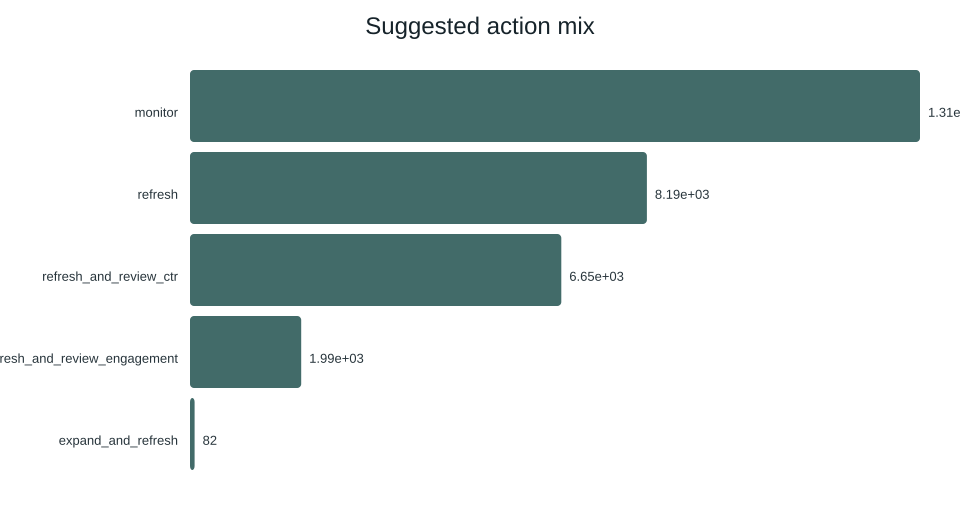


 confidence_mix.svg


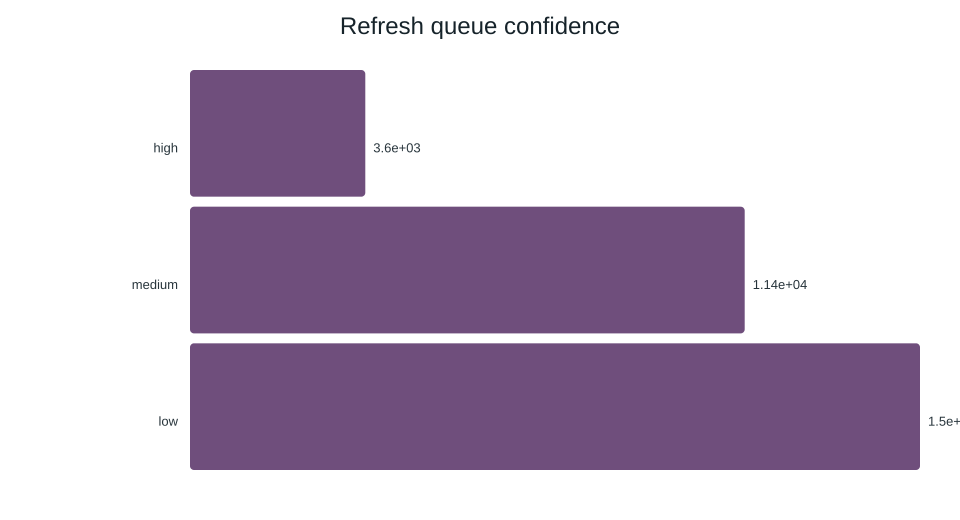


 top_feature_importance.svg


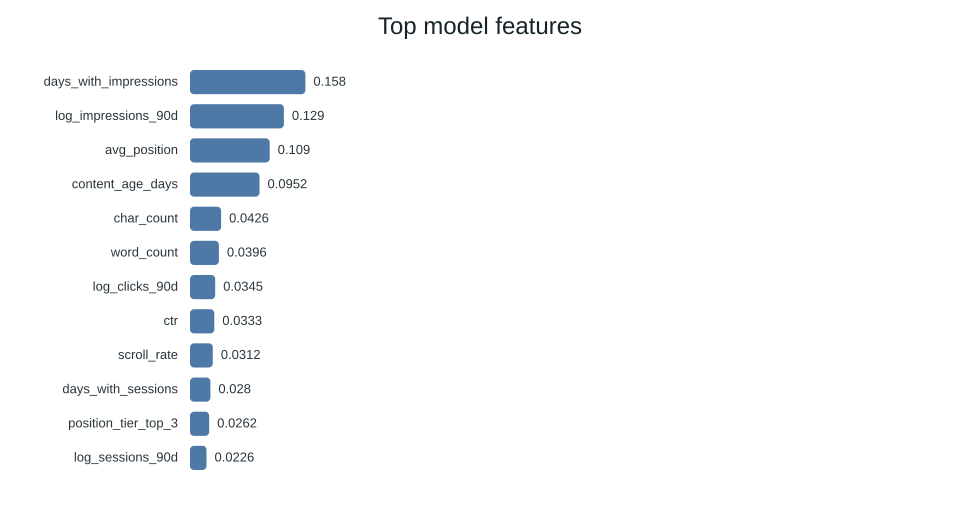


 top_reason_codes.svg


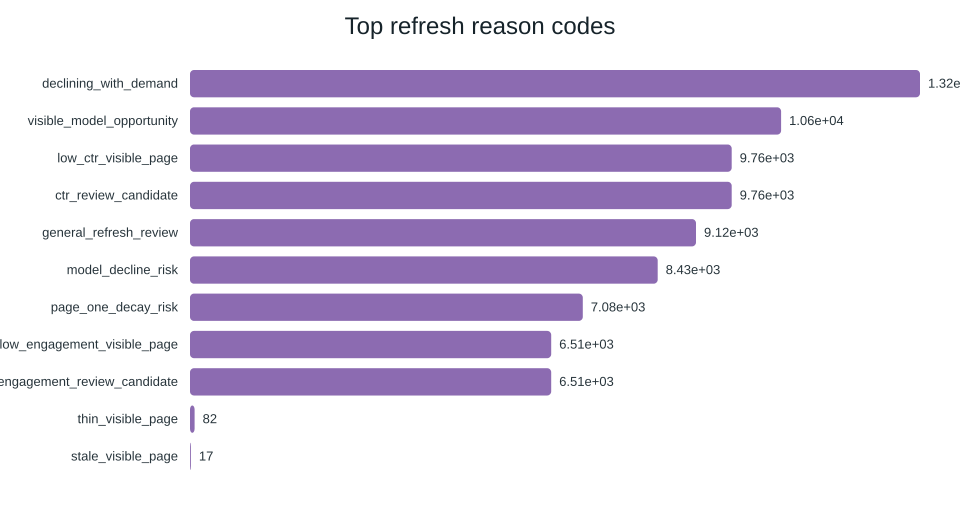


 trend_distribution.svg


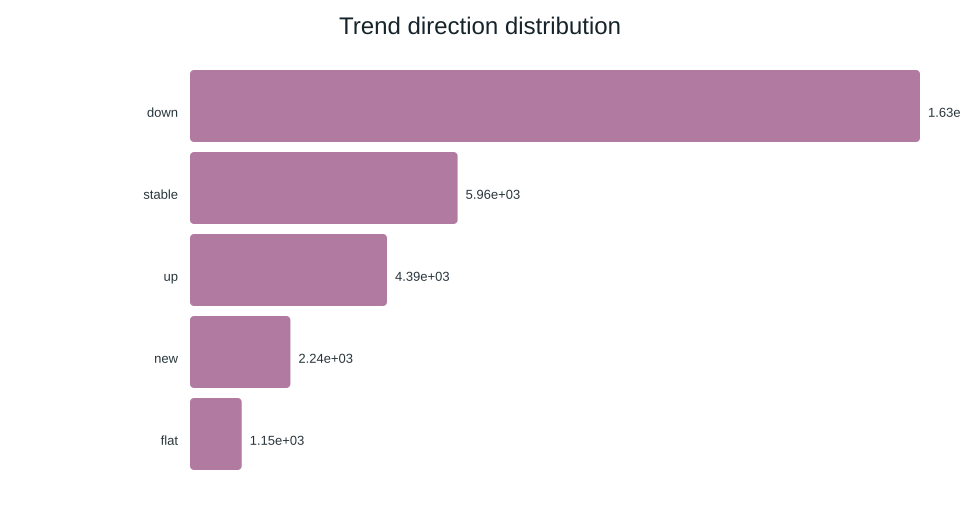


ARTIFACT FILE CHECK
✓ FOUND: outputs/model_results.json
✓ FOUND: outputs/refresh_queue.csv
✓ FOUND: outputs/model_report.md
✓ FOUND: outputs/flyrank_refresh_model_results.pdf

ARTIFACT SUMMARY
Model results: True
Refresh queue: True
Charts directory: True
Chart count: 5
Model report: True
PDF report: True

✓ Paper artifact collection check completed.


In [9]:
# ============================================================
# SECTION 7 — ARTIFACTS THE PAPER EMBEDS
# ============================================================

from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image, SVG, Markdown

ROOT = Path("/content/flyrank-ml-internship")
OUTPUTS = ROOT / "outputs"
CHARTS = OUTPUTS / "charts"

print("=" * 60)
print("CAPSTONE ARTIFACT CHECK")
print("=" * 60)


# ------------------------------------------------------------
# 1. MODEL RESULTS
# ------------------------------------------------------------

MODEL_RESULTS = OUTPUTS / "model_results.json"

if MODEL_RESULTS.exists():

    with open(MODEL_RESULTS, "r") as f:
        results = json.load(f)

    print("\n✓ model_results.json found")

    if "models" in results:
        metrics = pd.DataFrame(results["models"]).T
        print("\nModel evaluation results:")
        display(metrics)

else:
    print("\n✗ model_results.json not found")


# ------------------------------------------------------------
# 2. RANKED REFRESH QUEUE
# ------------------------------------------------------------

QUEUE = OUTPUTS / "refresh_queue.csv"

if QUEUE.exists():

    queue = pd.read_csv(QUEUE)

    print("\n✓ refresh_queue.csv found")
    print("Rows:", len(queue))

    print("\nTop 10 ranked recommendations:")
    display(queue.head(10))

else:
    print("\n✗ refresh_queue.csv not found")


# ------------------------------------------------------------
# 3. GENERATED CHARTS
# ------------------------------------------------------------

print("\nChecking generated charts...")

if CHARTS.exists():

    chart_files = sorted(
        list(CHARTS.glob("*.svg")) +
        list(CHARTS.glob("*.png")) +
        list(CHARTS.glob("*.jpg")) +
        list(CHARTS.glob("*.jpeg"))
    )

    print("Charts found:", len(chart_files))

    for chart in chart_files:

        print("\n", chart.name)

        if chart.suffix.lower() == ".svg":
            display(SVG(filename=str(chart)))
        else:
            display(Image(filename=str(chart)))

else:
    print("✗ Charts directory not found")


# ------------------------------------------------------------
# 4. OTHER PAPER ARTIFACTS
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("ARTIFACT FILE CHECK")
print("=" * 60)

artifact_paths = [
    OUTPUTS / "model_results.json",
    OUTPUTS / "refresh_queue.csv",
    OUTPUTS / "model_report.md",
    OUTPUTS / "flyrank_refresh_model_results.pdf",
]

for path in artifact_paths:
    status = "✓ FOUND" if path.exists() else "✗ MISSING"
    print(f"{status}: {path.relative_to(ROOT)}")


# ------------------------------------------------------------
# 5. SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("ARTIFACT SUMMARY")
print("=" * 60)

print("Model results:", MODEL_RESULTS.exists())
print("Refresh queue:", QUEUE.exists())
print("Charts directory:", CHARTS.exists())
print("Chart count:", len(chart_files) if CHARTS.exists() else 0)
print("Model report:", (OUTPUTS / "model_report.md").exists())
print("PDF report:", (OUTPUTS / "flyrank_refresh_model_results.pdf").exists())

print("\n✓ Paper artifact collection check completed.")

In [10]:
# ============================================================
# STEP 8 — GENERATE ALL CAPSTONE ARTIFACTS
# ============================================================

from pathlib import Path
import subprocess

ROOT = Path("/content/flyrank-ml-internship")
RUN_ALL = ROOT / "scripts" / "run_all.py"

print("Repository exists:", ROOT.exists())
print("Pipeline exists:", RUN_ALL.exists())

if not ROOT.exists():
    raise FileNotFoundError(f"Repository not found: {ROOT}")

if not RUN_ALL.exists():
    raise FileNotFoundError(f"Pipeline not found: {RUN_ALL}")

print("\nRunning the project pipeline...")
print("=" * 60)

result = subprocess.run(
    ["python", str(RUN_ALL)],
    cwd=str(ROOT),
    text=True
)

print("=" * 60)
print("Pipeline return code:", result.returncode)

if result.returncode != 0:
    raise RuntimeError("Pipeline failed. Check the output above.")

print("✓ Pipeline completed successfully")

Repository exists: True
Pipeline exists: True

Running the project pipeline...
Pipeline return code: 0
✓ Pipeline completed successfully


## ML-12 — 5-Minute Demo Outline

### 0:00–0:45 — Problem
Explain the research question: whether observable content and search-performance signals can prioritize pages for refresh review.

### 0:45–1:30 — Data
Introduce the anonymized dataset, its page-level records, available search/content signals, and the public-safe constraints.

### 1:30–2:15 — Method
Explain the declining-content label, feature vector, transparent baseline, Logistic Regression, Decision Tree, and Random Forest models.

### 2:15–3:15 — Validation and results
Explain the client-holdout validation design and compare model Precision@50 against the baseline.

### 3:15–4:15 — Ranked recommendations
Show how the final queue prioritizes pages and provides reason codes, confidence, and suggested actions for human review.

### 4:15–5:00 — Limitations and takeaway
Explain that the system is decision-support, not causal proof or autonomous content editing. End with the practical value of a transparent, reproducible prioritization workflow.

## ML-12 — Social-Post Cut

Built a content-refresh prioritization system using anonymized search and content-performance data.

I compared a transparent baseline with Logistic Regression, Decision Tree, and Random Forest models using client-holdout validation. The Random Forest achieved 0.74 Precision@50 versus 0.24 for the baseline, while the final output remains a human-review decision-support queue rather than an automated publishing system.

The project covers data contracts, leakage checks, model validation, ranked recommendations, and reproducible reporting.

## ML-12 — Employer-Facing Summary

I built an end-to-end ML decision-support pipeline that prioritizes content pages for refresh review using anonymized search, content, and engagement signals.

I implemented a transparent baseline, trained and compared three classification models, and evaluated them using a client-holdout split; Random Forest achieved 0.74 Precision@50 compared with 0.24 for the baseline.

The project demonstrates practical skills in feature engineering, leakage prevention, validation design, ranking-oriented evaluation, reproducible pipelines, and translating model outputs into actionable human-review recommendations.

## Self-check

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] Claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/`
- [x] Deployed paper contains all 9 required sections, including Abstract and Acknowledgments & data credit
- [x] ML-12 completed — 5-minute demo outline, social-post cut, and employer-facing summary